In [18]:
# --- loads our saved trained models and the data ---

%run ./r_model_data_loader.ipynb

Test shape: (685159, 191)
Weeks: 44 - 91 (48 unieke weken)
Default rate: 0.0335 (22955 positieven)
LR : C=0.000195172, l1_ratio=0.0, n_features=191
XGB: n_trees=450, n_features=191
MLP: hidden=[128], n_features=191
Device: cpu


c:\Users\Vik\Documents\UGent\Masterproef\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Results - Predictive Stability

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Results config ---
LAST_TRAIN_WEEK = 43
COVID_WEEK = 62

In [20]:
# Scores van de drie modellen op de volledige testset, en de wekelijkse basistabel
# (weekly_input) die zowel de ruischeck hieronder als F1/T1 verderop gebruiken. Alle drie
# modellen draaien op dezelfde preprocessede featureset, dus X_test kan ongewijzigd door.
@torch.no_grad()
def predict_mlp(model, X, batch=100_000):
    """Scores in batches: de volledige testset als float32-tensor is te groot voor een keer."""
    parts = [torch.sigmoid(model(torch.tensor(X.iloc[i:i + batch].to_numpy(dtype=np.float32),
                                              device=device))).cpu().numpy().ravel()
             for i in range(0, len(X), batch)]
    return np.concatenate(parts)


scores = pd.DataFrame({
    "LR": lr_best.predict_proba(X_test)[:, 1],
    "XGB": xgb_best.predict_proba(X_test)[:, 1],
    "MLP": predict_mlp(mlp_best, X_test),
})
MODELS = list(scores.columns)
colors = {"LR": "dimgray", "XGB": "crimson", "MLP": "darkorange"}

# WEEK_NUM als index, zodat de groepskolom niet in apply belandt. scores, y_test en
# week_num_test staan alle drie in dezelfde rijvolgorde (zie loader).
weekly_input = scores.copy()
weekly_input["target"] = y_test.to_numpy()
weekly_input.index = week_num_test.to_numpy()


## 3.2.0 Data ruis check

In [ ]:
# T4d - Bootstrap-SD check: hoeveel ruis zit er in een enkele week-gini, en hangt dat af
# van het aantal cases in die week? Voor de kleinste en de grootste testweek wordt binnen
# die week 1000x met teruglegging geresampled (zelfde n als de week zelf), telkens de
# gini herberekend. De spreiding (SD) van die bootstrap-verdeling is een directe schatting
# van de standaardfout van de week-gini zelf, en die vergelijken we hier tussen een kleine
# en een grote week.
rng = np.random.default_rng(0)
N_BOOT = 1000

week_sizes = weekly_input.groupby(level=0).size()
week_small, week_large = int(week_sizes.idxmin()), int(week_sizes.idxmax())


def bootstrap_gini_sd(g, n_boot, rng):
    n = len(g)
    target = g["target"].to_numpy()
    scores = {m: g[m].to_numpy() for m in MODELS}
    boot = {m: np.empty(n_boot) for m in MODELS}
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        y = target[idx]
        for m in MODELS:
            boot[m][i] = gini(y, scores[m][idx])
    return pd.Series({m: boot[m].std() for m in MODELS})


boot_rows = {}
for week in [week_small, week_large]:
    g = weekly_input.loc[[week]]
    boot_rows[f"week {week} (n={len(g)})"] = bootstrap_gini_sd(g, N_BOOT, rng)

gini_boot_sd = pd.DataFrame(boot_rows).T
gini_boot_sd.loc["ratio (klein / groot)"] = gini_boot_sd.iloc[0] / gini_boot_sd.iloc[1]

print(f"Bootstrap-SD van de wekelijkse gini ({N_BOOT} resamples), kleinste vs grootste week")
gini_boot_sd.round(4)


# Conclusie: er is ruis dus we moeten voorzichtig zijn met de direct interpretatie van de wekelijkse gini's

Bootstrap-SD van de wekelijkse gini (1000 resamples), kleinste vs grootste week


,LR,XGB,MLP
week 68 (n=825),0.0761,0.0642,0.0694
week 51 (n=35920),0.0114,0.0109,0.0110
ratio (klein / groot),6.6712,5.8679,6.3094


## 3.2.1 Mean(gini)

Gini per week berekend voor 48 weken (44-91)
Gini gepoold over de volledige testset:   LR 0.6347   XGB 0.6510   MLP 0.6439


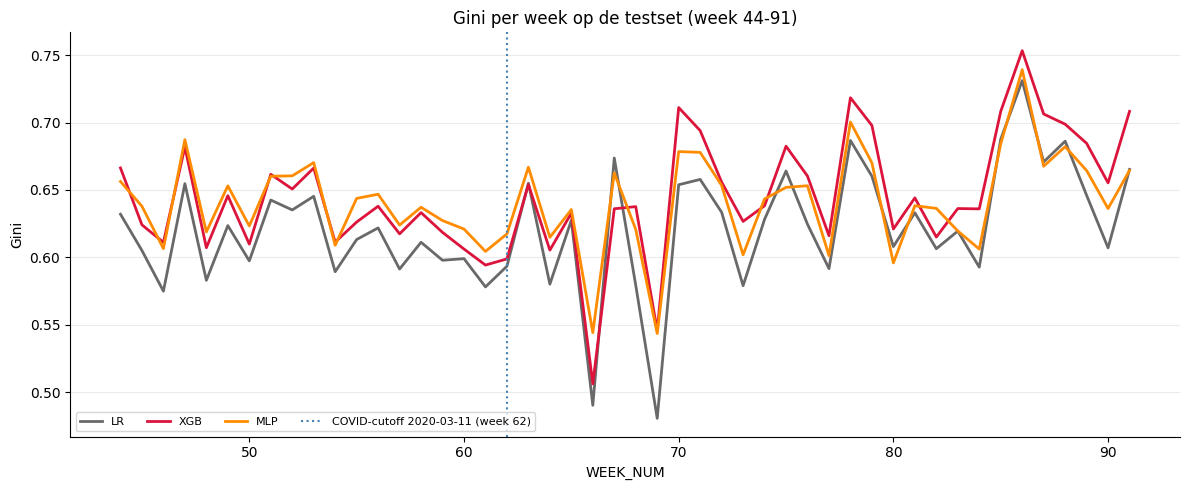

In [22]:
# F1 - Gini per week op de testset, per model.
gini_weekly = weekly_input.groupby(level=0).apply(
    lambda g: pd.Series({m: gini(g["target"], g[m]) for m in MODELS}))
gini_weekly.index.name = "WEEK_NUM"

print(f"Gini per week berekend voor {len(gini_weekly)} weken "
      f"({gini_weekly.index.min()}-{gini_weekly.index.max()})")
print("Gini gepoold over de volledige testset:   "
      + "   ".join(f"{m} {gini(y_test, scores[m]):.4f}" for m in MODELS))

fig, ax = plt.subplots(figsize=(12, 5))

for model_name in MODELS:
    ax.plot(gini_weekly.index, gini_weekly[model_name], linewidth=2,
            color=colors[model_name], label=model_name)

ax.axvline(COVID_WEEK, color="steelblue", linestyle=":", linewidth=1.5,
           label=f"COVID-cutoff 2020-03-11 (week {COVID_WEEK})")

ax.set_xlabel("WEEK_NUM")
ax.set_ylabel("Gini")
ax.set_title(f"Gini per week op de testset (week {gini_weekly.index.min()}-"
             f"{gini_weekly.index.max()})")
ax.legend(loc="lower left", fontsize=8, ncol=4)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

In [35]:
# T1 - Mean(gini) per model: ongewogen gemiddelde van de wekelijkse gini's uit F1, over
# het volledige testvenster en per COVID-blok, met de sd van diezelfde weekgini's ernaast
# (ruwe spreiding rond het blokgemiddelde, niet gedetrend - dat is de std_residuals in
# T4, rond de bloktrend in plaats van rond het gemiddelde). De delta wordt ongepaard
# getoetst - pre en post zijn verschillende weken - met Welch (ongelijke varianties) en
# Mann-Whitney ernaast. Met 18 tegen 30 weken, waarvan de post-weken de ruizigste zijn,
# heeft die toets weinig onderscheidend vermogen: een niet-significante uitkomst is dus
# geen bewijs dat de gini gelijk bleef. De maskers worden hieronder hergebruikt.
from scipy import stats

blocks = {
    f"volledig ({gini_weekly.index.min()}-{gini_weekly.index.max()})": gini_weekly.index > -1,
    f"pre-COVID ({LAST_TRAIN_WEEK + 1}-{COVID_WEEK - 1})": gini_weekly.index < COVID_WEEK,
    f"post-COVID ({COVID_WEEK}-{gini_weekly.index.max()})": gini_weekly.index >= COVID_WEEK,
}
full_name, pre_name, post_name = blocks

block_stats = {}
for name, mask in blocks.items():
    block_stats[name] = gini_weekly[mask].mean()
    block_stats[f"sd ({name.split(' (')[0]})"] = gini_weekly[mask].std()

gini_blocks = pd.DataFrame(block_stats)
gini_blocks["delta (post - pre)"] = gini_blocks[post_name] - gini_blocks[pre_name]

block_tests = {}
for m in MODELS:
    pre_values = gini_weekly.loc[blocks[pre_name], m]
    post_values = gini_weekly.loc[blocks[post_name], m]
    block_tests[m] = {
        "p (Welch)": stats.ttest_ind(post_values, pre_values, equal_var=False).pvalue,
        "p (Mann-Whitney)": stats.mannwhitneyu(post_values, pre_values).pvalue}

gini_blocks = gini_blocks.join(pd.DataFrame(block_tests).T)
gini_blocks.index.name = "model"

print(f"T1  Mean(gini) per model (delta ongepaard getoetst over "
      f"{int(blocks[pre_name].sum())} pre- tegen {int(blocks[post_name].sum())} post-weken)")
gini_blocks.round(4)

T1  Mean(gini) per model (delta ongepaard getoetst over 18 pre- tegen 30 post-weken)


,volledig (44-91),sd (volledig),pre-COVID (44-61),sd (pre-COVID),post-COVID (62-91),sd (post-COVID),delta (post - pre),p (Welch),p (Mann-Whitney)
model,,,,,,,,,
LR,0.6210,0.0455,0.6109,0.0242,0.6271,0.0539,0.0162,0.1606,0.0624
XGB,0.6449,0.0450,0.6316,0.0253,0.6528,0.0522,0.0212,0.0661,0.0465
MLP,0.6408,0.0359,0.6382,0.0234,0.6424,0.0420,0.0042,0.6585,0.5725


### Bijkomende robuustheid checks

In [24]:
# T1b - stratisfied downsampling van elke week naar kleinste week om te zien wat met gini
def stratified_sample(g, n, rng):
    pos_idx = np.flatnonzero(g["target"].to_numpy() == 1)
    neg_idx = np.flatnonzero(g["target"].to_numpy() == 0)
    n_pos = min(len(pos_idx), round(n * len(pos_idx) / len(g)))
    n_neg = min(n - n_pos, len(neg_idx))
    idx = np.concatenate([rng.choice(pos_idx, n_pos, replace=False),
                           rng.choice(neg_idx, n_neg, replace=False)])
    return g.iloc[idx]


rng = np.random.default_rng(0)
n_min = int(weekly_input.groupby(level=0).size().min())
equal_weekly_strat = weekly_input.groupby(level=0, group_keys=False).apply(
    lambda g: stratified_sample(g, n_min, rng))

gini_weekly_eq_strat = equal_weekly_strat.groupby(level=0).apply(
    lambda g: pd.Series({m: gini(g["target"], g[m]) for m in MODELS}))
gini_weekly_eq_strat.index.name = "WEEK_NUM"

gini_blocks_eq_strat = pd.DataFrame(
    {name: gini_weekly_eq_strat[mask].mean() for name, mask in blocks.items()})
gini_blocks_eq_strat["delta (post - pre)"] = (
    gini_blocks_eq_strat[post_name] - gini_blocks_eq_strat[pre_name])

print(f"T1b  Controletest (stratified): elke week teruggebracht tot n={n_min}, "
      "wekelijkse default rate behouden")
print("Verschil met T1 (gelijkgetrokken n, stratified - origineel):")
(gini_blocks_eq_strat - gini_blocks[gini_blocks_eq_strat.columns]).round(4)


T1b  Controletest (stratified): elke week teruggebracht tot n=825, wekelijkse default rate behouden
Verschil met T1 (gelijkgetrokken n, stratified - origineel):


,volledig (44-91),pre-COVID (44-61),post-COVID (62-91),delta (post - pre)
LR,-0.0037,-0.0078,-0.0012,0.0067
XGB,-0.0007,-0.0020,0.0000,0.0020
MLP,0.0022,0.0020,0.0023,0.0003


In [25]:
# T2 - Gepaarde weekvergelijking tussen de modellen. De drie reeksen draaien op dezelfde
# weken en delen dus dezelfde weekruis; door per week het verschil te nemen valt die
# gedeelde ruis weg. Wilcoxon is de verdelingsvrije tegenhanger van de gepaarde t-test en
# is bij 48 weken de veiligere van de twee. Het onderpaneel telt hoe vaak elk model de
# hoogste gini haalde: dat vangt op of een klein gemiddeld verschil door alle weken heen
# loopt of door enkele weken wordt gemaakt.
PAIRS = [("XGB", "LR"), ("MLP", "LR"), ("XGB", "MLP")]

pair_rows = {}
for a, b in PAIRS:
    d = gini_weekly[a] - gini_weekly[b]
    pair_rows[f"{a} - {b}"] = {
        **{name: d[mask].mean() for name, mask in blocks.items()},
        "sd (volledig)": d.std(),
        "p (Wilcoxon)": stats.wilcoxon(gini_weekly[a], gini_weekly[b]).pvalue}

gini_pairs = pd.DataFrame(pair_rows).T.rename_axis("verschil")
print(f"T2  Gemiddeld verschil in wekelijkse gini, gepaard over {len(gini_weekly)} weken")
print(gini_pairs.round(4).to_string())

# Per blok het aantal weken waarin het model de hoogste gini van de drie haalde; de
# kolomkop draagt het aantal weken in dat blok, zodat de tellingen optellen tot de kop.
win_counts = pd.DataFrame(
    {f"{name.split(' (')[0]} ({mask.sum()})":
        {m: (gini_weekly[mask].idxmax(axis=1) == m).sum() for m in MODELS}
     for name, mask in blocks.items()}).rename_axis("weken met hoogste gini")

print("\nAantal weken waarin elk model de hoogste gini haalde")
print(win_counts.to_string())

T2  Gemiddeld verschil in wekelijkse gini, gepaard over 48 weken
           volledig (44-91)  pre-COVID (44-61)  post-COVID (62-91)  sd (volledig)  p (Wilcoxon)
verschil                                                                                       
XGB - LR             0.0239             0.0208              0.0257         0.0172        0.0000
MLP - LR             0.0198             0.0273              0.0153         0.0158        0.0000
XGB - MLP            0.0041            -0.0065              0.0104         0.0183        0.1791

Aantal weken waarin elk model de hoogste gini haalde
                        volledig (48)  pre-COVID (18)  post-COVID (30)
weken met hoogste gini                                                
LR                                  1               0                1
XGB                                26               4               22
MLP                                21              14                7


In [26]:
# Onderbouwing bij T3: lopen de drie reeksen synchroon? Een hoge correlatie betekent dat
# het weekpatroon van de week komt (weeksamenstelling, conjunctuur) en niet van het
# model. Dat is precies de gedeelde ruis die de gepaarde toets in T2 wegdeelt, en de
# reden waarom een gemiddeld verschil van enkele gini-punten daar toch significant is.
gini_corr = gini_weekly.corr()

print("Correlatie tussen de wekelijkse gini-reeksen (Pearson), volledig testvenster")
print(gini_corr.round(3).to_string())

Correlatie tussen de wekelijkse gini-reeksen (Pearson), volledig testvenster
        LR    XGB    MLP
LR   1.000  0.927  0.951
XGB  0.927  1.000  0.922
MLP  0.951  0.922  1.000


## 3.2.2 Min(0,a)

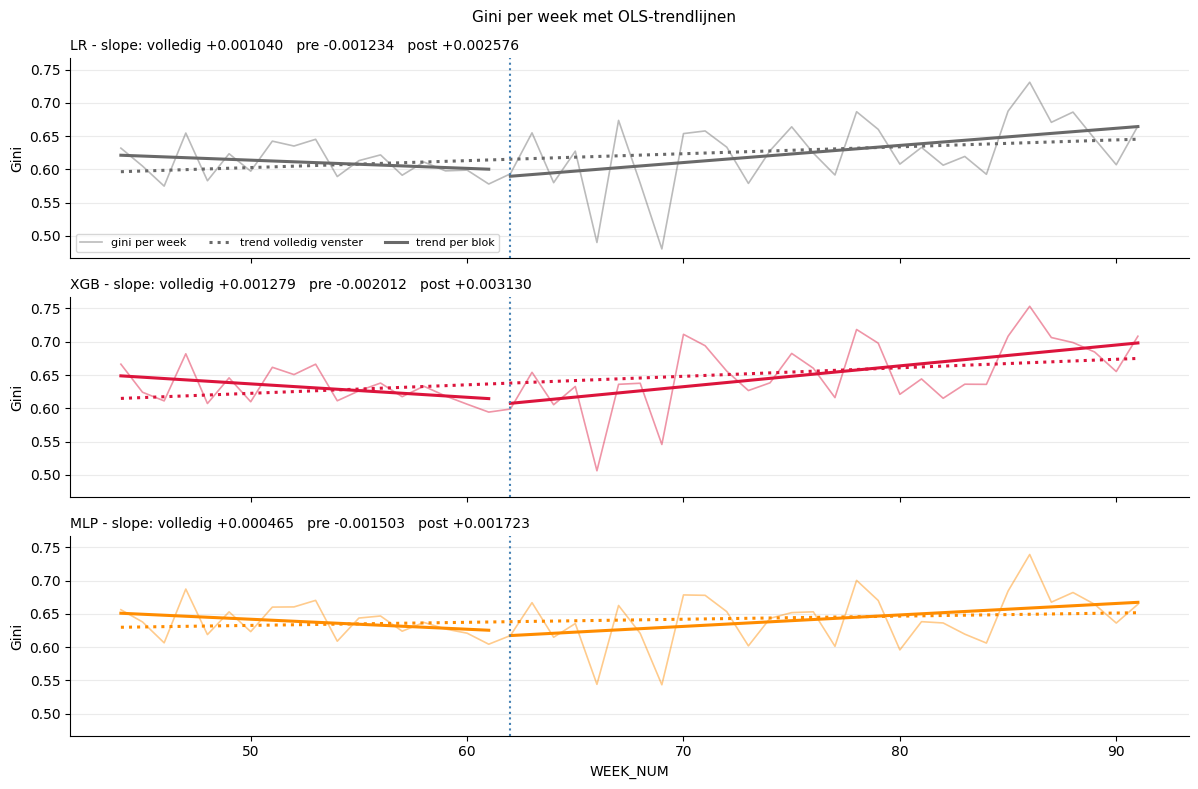

In [27]:
# F2 - OLS-trendlijn van de wekelijkse gini per blok en per model, ter illustratie van de
# helling die hieronder in T3 robuust (HAC + Theil-Sen) getoetst wordt. Een paneel per
# model zodat de trendlijnen niet over elkaar vallen: de weekreeks licht op de
# achtergrond, daarover de trend per blok (vol) en over het volledige venster
# (gestippeld). Het grijze vlak is het pre-COVID blok, het enige stuk met a < 0 en dus
# het enige stuk dat via min(0, a) meetelt.
from scipy import stats

trend_fits = {
    (model_name, name): stats.linregress(
        gini_weekly.index[mask].to_numpy(dtype=float),
        gini_weekly.loc[mask, model_name].to_numpy())
    for name, mask in blocks.items() for model_name in MODELS
}

fig, axes = plt.subplots(len(MODELS), 1, figsize=(12, 8), sharex=True, sharey=True)

for ax, model_name in zip(axes, MODELS):
    ax.plot(gini_weekly.index, gini_weekly[model_name], color=colors[model_name],
            linewidth=1.2, alpha=0.45, label="gini per week")
    for name, mask in blocks.items():
        weeks = gini_weekly.index[mask].to_numpy(dtype=float)
        fit = trend_fits[model_name, name]
        ax.plot(weeks, fit.intercept + fit.slope * weeks, color=colors[model_name],
                linewidth=2.2, linestyle=":" if name == full_name else "-",
                label="trend volledig venster" if name == full_name else
                      ("trend per blok" if name == pre_name else None))

    ax.axvline(COVID_WEEK, color="steelblue", linestyle=":", linewidth=1.5)
    slopes = "   ".join(f"{label} {trend_fits[model_name, name].slope:+.6f}"
                        for label, name in [("volledig", full_name), ("pre", pre_name),
                                            ("post", post_name)])
    ax.set_title(f"{model_name} - slope: {slopes}",
                 fontsize=10, loc="left")
    ax.set_ylabel("Gini")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(loc="lower left", fontsize=8, ncol=3)
axes[-1].set_xlabel("WEEK_NUM")
fig.suptitle(f"Gini per week met OLS-trendlijnen", fontsize=11)
fig.tight_layout()
plt.show()

In [28]:
# T3 - HAC-robuuste helling (Newey-West) van de wekelijkse gini per model en blok, met
# Theil-Sen ernaast als non-parametrische robuustheidscheck: wijkt die sterk af van de
# OLS-helling uit F2 hierboven, dan trekken uitschieters die schatting scheef. De
# degradatieterm 88 * min(0, helling) is enkel negatief in het pre-COVID blok, het enige
# stuk met een dalende trend.

import numpy as np
import statsmodels.api as sm
from scipy.stats import theilslopes

def trend_per_model(week, gini, naam):
    y = np.asarray(gini, float)
    t = np.asarray(week, float) - np.min(week)
    n = len(t)
    L = max(int(np.floor(4 * (n / 100) ** (2 / 9))), 1)
    tc = t - t.mean()                      # centreren: intercept = gemiddelde gini

    res = sm.OLS(y, sm.add_constant(tc)).fit(
        cov_type="HAC", cov_kwds={"maxlags": L}, use_t=True
    )
    a = res.params[1]
    lo, hi = res.conf_int()[1]

    return {
        "model": naam,
        "n": n,
        "gem_gini": res.params[0],
        "helling": a,
        "ci_laag": lo,
        "ci_hoog": hi,
        "p": res.pvalues[1],
        "helling_theilsen": theilslopes(y, t)[0],
        "degradatieterm": 88.0 * min(0.0, a),
        "std_residuals": res.resid.std(),
    }


rows = []
for block_name, mask in blocks.items():
    blok = block_name.split(" (")[0]
    for model_name in MODELS:
        row = trend_per_model(gini_weekly.index[mask], gini_weekly.loc[mask, model_name],
                               model_name)
        row["blok"] = blok
        rows.append(row)

gini_trend_hac = pd.DataFrame(rows).set_index(["model", "blok"])

print("T3  HAC-trend van de wekelijkse gini per model en blok "
      "(Newey-West standaardfouten, Theil-Sen als robuustheidscheck)")
gini_trend_hac.round(4)

T3  HAC-trend van de wekelijkse gini per model en blok (Newey-West standaardfouten, Theil-Sen als robuustheidscheck)


,,n,gem_gini,helling,ci_laag,ci_hoog,p,helling_theilsen,degradatieterm,std_residuals
model,blok,,,,,,,,,
LR,volledig,48,0.6210,0.0010,0.0002,0.0019,0.0135,0.0009,0.0000,0.0426
XGB,volledig,48,0.6449,0.0013,0.0004,0.0022,0.0070,0.0011,0.0000,0.0408
MLP,volledig,48,0.6408,0.0005,-0.0002,0.0012,0.1949,0.0004,0.0000,0.0350
LR,pre-COVID,18,0.6109,-0.0012,-0.0028,0.0003,0.1105,-0.0017,-0.1086,0.0226
XGB,pre-COVID,18,0.6316,-0.0020,-0.0035,-0.0005,0.0112,-0.0024,-0.1771,0.0222
MLP,pre-COVID,18,0.6382,-0.0015,-0.0029,-0.0001,0.0415,-0.0018,-0.1322,0.0213
LR,post-COVID,30,0.6271,0.0026,0.0009,0.0043,0.0044,0.0017,0.0000,0.0481
XGB,post-COVID,30,0.6528,0.0031,0.0015,0.0047,0.0004,0.0027,0.0000,0.0436
MLP,post-COVID,30,0.6424,0.0017,0.0004,0.0030,0.0127,0.0012,0.0000,0.0385


## 3.2.3 Volatiliteit -> std(residuals)

In [29]:
# T4 - Volatiliteit van de wekelijkse gini: std(residuals) rond de bloktrend uit T3, dus
# de spreiding die overblijft nadat de helling eruit is. Het niveau staat al in T3; wat
# hier bijkomt is de onzekerheid erop. Die komt uit een moving-block bootstrap: blokken
# van L aaneengesloten weken (dezelfde Newey-West lag als in T3) worden met teruglegging
# aan elkaar geplakt tot een reeks van n weken. Losse weken herbemonsteren zou de
# autocorrelatie tussen opeenvolgende weken breken en het interval te smal maken.
# Elke replicatie gebruikt dezelfde weken voor de drie modellen - dezelfde gedeelde
# weekruis die T2 gepaard wegdeelt - zodat aandeel_laagste een gepaarde rangtelling is:
# in welk deel van de replicaties dit model de laagste volatiliteit had. Twee kanttekeningen:
# de intervallen van de drie modellen overlappen sterk en mogen niet los van elkaar als
# toets gelezen worden (daarvoor is aandeel_laagste er), en T4d laat zien dat een deel van
# deze spreiding gewoon steekproefruis op de week-gini zelf is - dat is de ondergrens.
B_VOLA = 5000


def _resid(X, Y):
    """Residuen van de kolommen van Y na OLS op X; Y mag meerdere modellen tegelijk zijn."""
    return Y - X @ np.linalg.lstsq(X, Y, rcond=None)[0]


def _blok_idx(n, L, rng):
    """Moving-block indices: aaneengesloten stukken van L weken tot er n weken staan."""
    starts = rng.integers(0, n - L + 1, size=int(np.ceil(n / L)))
    return np.concatenate([np.arange(s, s + L) for s in starts])[:n]


def blok_residuals(week, gini_blok):
    """Wekelijkse gini min de OLS-trend van dat blok, per model - de reeks achter T4 en F3."""
    t = np.asarray(week, dtype=float)
    X = np.column_stack([np.ones(len(t)), t - t.min()])
    return pd.DataFrame(_resid(X, gini_blok[MODELS].to_numpy(dtype=float)),
                        index=week, columns=MODELS)


def vola_per_blok(week, gini_blok, B=B_VOLA, seed=42):
    rng = np.random.default_rng(seed)
    t = np.asarray(week, dtype=float)
    t -= t.min()
    n = len(t)
    L = max(int(np.floor(4 * (n / 100) ** (2 / 9))), 1)   # zelfde bloklengte als de lag in T3
    X = np.column_stack([np.ones(n), t])
    Y = gini_blok[MODELS].to_numpy(dtype=float)           # n x 3: de modellen in een keer

    # ddof=0, net als res.resid.std() in T3, zodat std_residuals daar exact mee matcht
    obs = _resid(X, Y).std(axis=0)
    boots = np.empty((B, len(MODELS)))
    for b in range(B):
        idx = _blok_idx(n, L, rng)                        # dezelfde weken voor alle modellen
        boots[b] = _resid(X[idx], Y[idx]).std(axis=0)

    laagste = np.asarray(MODELS)[boots.argmin(axis=1)]
    return pd.DataFrame({
        "model": MODELS,
        "n": n,
        "L": L,
        "std_residuals": obs,
        "ci_laag": np.percentile(boots, 2.5, axis=0),
        "ci_hoog": np.percentile(boots, 97.5, axis=0),
        "aandeel_laagste": [(laagste == m).mean() for m in MODELS],
    })


vola_rows = []
for block_name, mask in blocks.items():
    tabel = vola_per_blok(gini_weekly.index[mask], gini_weekly[mask])
    tabel["blok"] = block_name.split(" (")[0]
    vola_rows.append(tabel)

gini_vola = pd.concat(vola_rows).set_index(["model", "blok"])

# Controle dat we dezelfde residuspreiding meten als T3 rapporteert
afwijking = (gini_vola["std_residuals"] - gini_trend_hac["std_residuals"]).abs().max()

print(f"T4  Volatiliteit van de wekelijkse gini: std(residuals) rond de bloktrend, "
      f"moving-block bootstrap ({B_VOLA} replicaties)")
print(f"    grootste afwijking t.o.v. std_residuals in T3: {afwijking:.1e}")
gini_vola.round(4)

T4  Volatiliteit van de wekelijkse gini: std(residuals) rond de bloktrend, moving-block bootstrap (5000 replicaties)
    grootste afwijking t.o.v. std_residuals in T3: 2.1e-17


,,n,L,std_residuals,ci_laag,ci_hoog,aandeel_laagste
model,blok,,,,,,
LR,volledig,48,3,0.0426,0.0290,0.0543,0.0064
XGB,volledig,48,3,0.0408,0.0296,0.0493,0.0046
MLP,volledig,48,3,0.0350,0.0261,0.0424,0.9890
LR,pre-COVID,18,2,0.0226,0.0145,0.0283,0.0350
XGB,pre-COVID,18,2,0.0222,0.0144,0.0273,0.3318
MLP,pre-COVID,18,2,0.0213,0.0131,0.0276,0.6332
LR,post-COVID,30,3,0.0481,0.0334,0.0599,0.0096
XGB,post-COVID,30,3,0.0436,0.0322,0.0530,0.0352
MLP,post-COVID,30,3,0.0385,0.0294,0.0458,0.9552


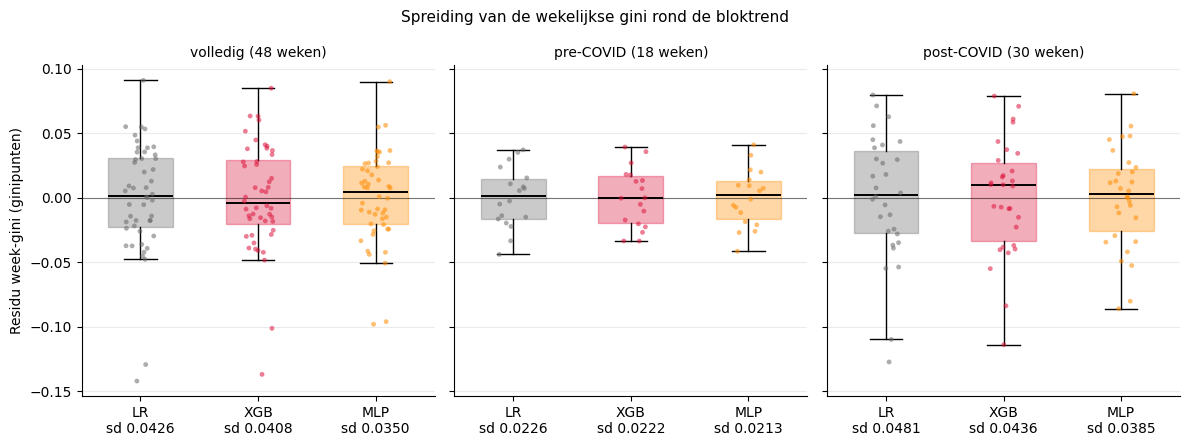

Kwartielen en snorharen van de residuen per model en blok (zelfde eenheid als de as hierboven)


,,wisker_laag,Q1,Q2 (mediaan),Q3,wisker_hoog
model,blok,,,,,
LR,volledig,-0.0478,-0.0223,0.0016,0.0310,0.0909
XGB,volledig,-0.0484,-0.0201,-0.0045,0.0293,0.0848
MLP,volledig,-0.0508,-0.0205,0.0041,0.0246,0.0899
LR,pre-COVID,-0.0440,-0.0162,0.0014,0.0142,0.0370
XGB,pre-COVID,-0.0336,-0.0196,-0.0002,0.0165,0.0392
MLP,pre-COVID,-0.0415,-0.0169,0.0021,0.0128,0.0409
LR,post-COVID,-0.1099,-0.0276,0.0022,0.0365,0.0795
XGB,post-COVID,-0.1139,-0.0334,0.0095,0.0268,0.0787
MLP,post-COVID,-0.0860,-0.0260,0.0029,0.0225,0.0805


In [30]:
# F3 - Verdeling van de residuen uit T4, per model en per blok. De residuen zijn de
# wekelijkse gini min de OLS-bloktrend en zijn per constructie gemiddeld nul: de figuur
# toont dus zuiver spreiding, los van het niveau (T1) en de helling (T3). De box is de
# IQR met de mediaan, de snorharen lopen tot 1.5 x IQR; de punten zijn de weken zelf,
# zodat zichtbaar blijft of een brede box van alle weken komt of van enkele uitschieters.
# De sd onder elke box is de std_residuals uit T4, in dezelfde eenheid als de as.

resid_blok = {block_name.split(" (")[0]: blok_residuals(gini_weekly.index[mask],
                                                        gini_weekly[mask])
              for block_name, mask in blocks.items()}

fig, axes = plt.subplots(1, len(resid_blok), figsize=(12, 4.5), sharey=True)
rng = np.random.default_rng(0)
wiskers_blok = {}

for ax, (blok, resid) in zip(axes, resid_blok.items()):
    box = ax.boxplot([resid[m] for m in MODELS], patch_artist=True, widths=0.55,
                     showfliers=False, medianprops=dict(color="black", linewidth=1.4))
    for patch, model_name in zip(box["boxes"], MODELS):
        patch.set(facecolor=colors[model_name], alpha=0.35, edgecolor=colors[model_name])

    # De caps zijn de horizontale streepjes aan het einde van elke snorhaar - de
    # daadwerkelijk getekende grens, i.p.v. die opnieuw met 1.5 x IQR te herberekenen.
    wiskers_blok[blok] = {m: (box["caps"][2 * i].get_ydata()[0], box["caps"][2 * i + 1].get_ydata()[0])
                          for i, m in enumerate(MODELS)}

    for i, model_name in enumerate(MODELS, start=1):
        y = resid[model_name].to_numpy()
        ax.scatter(i + rng.uniform(-0.13, 0.13, len(y)), y, s=12, alpha=0.55,
                   color=colors[model_name], edgecolors="none", zorder=3)

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xticks(range(1, len(MODELS) + 1))
    ax.set_xticklabels([f"{m}\nsd {gini_vola.loc[(m, blok), 'std_residuals']:.4f}"
                        for m in MODELS])
    ax.set_title(f"{blok} ({len(resid)} weken)", fontsize=10)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Residu week-gini (ginipunten)")
fig.suptitle("Spreiding van de wekelijkse gini rond de bloktrend", fontsize=11)
fig.tight_layout()
plt.show()

# Kwartielen en snorharen van de residuen, zelfde data als de boxplots hierboven
# (showfliers=False verbergt enkel de punten voorbij de snorharen, niet de box zelf).
kwartiel_rows = [
    {"model": m, "blok": blok,
     "wisker_laag": wiskers_blok[blok][m][0], "Q1": q[m][0.25], "Q2 (mediaan)": q[m][0.5],
     "Q3": q[m][0.75], "wisker_hoog": wiskers_blok[blok][m][1]}
    for blok, resid in resid_blok.items()
    for q in [resid[MODELS].quantile([0.25, 0.5, 0.75])]
    for m in MODELS
]
gini_resid_kwartielen = pd.DataFrame(kwartiel_rows).set_index(["model", "blok"])

print("Kwartielen en snorharen van de residuen per model en blok (zelfde eenheid als de as hierboven)")
gini_resid_kwartielen.round(4)

## 3.2.4 Gini stability metric

In [33]:
# T5 - Volledige gini stability metric (Kaggle Home Credit-definitie):
#   stability = gem(gini) + 88 * min(0, helling) - 0.5 * std_residuals
# De eerste twee termen staan al in T3, de derde in T4; hier staan ze naast elkaar en
# opgeteld tot de uiteindelijke metric, per model en per blok. Het degradatiedeel is
# alleen negatief in het pre-COVID blok (de enige dalende trend, zie T3); het
# volatiliteitsdeel is per constructie nooit positief.
stability_rows = []
for (model_name, blok), row in gini_trend_hac.iterrows():
    degradatie = row["degradatieterm"]
    volatiliteit = -0.5 * row["std_residuals"]
    stability_rows.append({
        "model": model_name,
        "blok": blok,
        "gem_gini": row["gem_gini"],
        "88 * min(0, helling)": degradatie,
        "-0.5 * std_residuals": volatiliteit,
        "stability_metric": row["gem_gini"] + degradatie + volatiliteit,
    })

gini_stability = pd.DataFrame(stability_rows).set_index(["model", "blok"]).sort_index()

print("T5  Gini stability metric per model en blok, met deelelementen")
gini_stability.round(4)

T5  Gini stability metric per model en blok, met deelelementen


gem_gini  88 * min(0, helling)  -0.5 * std_residuals  \
model blok                                                               
LR    post-COVID    0.6271                0.0000               -0.0240   
      pre-COVID     0.6109               -0.1086               -0.0113   
      volledig      0.6210                0.0000               -0.0213   
MLP   post-COVID    0.6424                0.0000               -0.0192   
      pre-COVID     0.6382               -0.1322               -0.0107   
      volledig      0.6408                0.0000               -0.0175   
XGB   post-COVID    0.6528                0.0000               -0.0218   
      pre-COVID     0.6316               -0.1771               -0.0111   
      volledig      0.6449                0.0000               -0.0204   

                  stability_metric  
model blok                          
LR    post-COVID            0.6030  
      pre-COVID             0.4909  
      volledig              0.5997  
MLP   post-COVID            0.6231  
      pre-COVID             0.4953  
      volledig              0.6233  
XGB   post-COVID            0.6310  
      pre-COVID             0.4435  
      volledig              0.6245